<a href="https://colab.research.google.com/github/TinyZhen/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

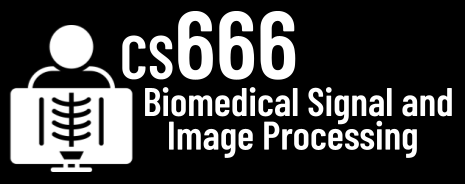
#Assignment 4

In [ ]:
# NAME:Zhen Lu

In [ ]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [ ]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
# we are using mahotas again, so lets install it!
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 39.3 MB/s eta 0:00:00


In [ ]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [ ]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [ ]:
!wget https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1

--2026-04-15 14:39:40--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc643f844410f050c4063e9252fa.dl.dropboxusercontent.com/cd/0/inline/C-pgNC6xNppDINEna83WoRu2S8rabwftU8xnS5XFXjVfYIY4oaapjraekST99HByI2Yc6iobwbtwNOnYUHp7Ll879re5mLfI_SsYtBPGsHbShieY51KElktbjTlzvuKnU_E/file# [following]
--2026-04-15 14:39:41--  https://uc643f844410f050c4063e9252fa.dl.dropboxusercontent.com/cd/0/inline/C-pgNC6xNppDINEna83WoRu2S8rabwftU8xnS5XFXjVfYIY4oaapjraekST99HByI2Yc6iobwbtwNOnYUHp7Ll879re5mLfI_SsYtBPGsHbShieY51KElktbjTlzvuKnU_E/file
Resolving uc643f844410f050c4063e9252fa.dl.dropboxusercontent.com (uc643f844410f050c4063e9252fa.dl.dropboxusercontent.com)... 162.125.65.15, 2620:100:6021:15::a27d:410f
Connecting to uc643f

In [ ]:

!mv "xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl" xray.zip

!ls

mv: cannot stat 'xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl': No such file or directory
index.html  index.html.1  sample_data  xray.zip


In [ ]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [ ]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [ ]:
# TODO: Please display this image and print the dimensions!


In [ ]:
# TODO: YOUR CODE

(1858, 2090)


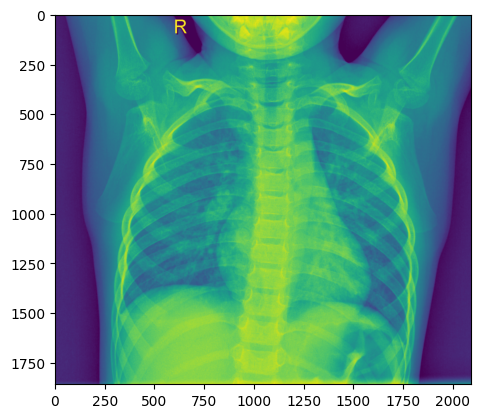

In [23]:
imshow(img)
print(img.shape)

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [24]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [ ]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) Grayscale conversion (RGB to single channel)
# TODO: Operation 2) image resizing to fixed resolution( 300x300)
# TODO: Operation 3) Zero- padding

In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

In [ ]:
# TODO: YOUR CODE

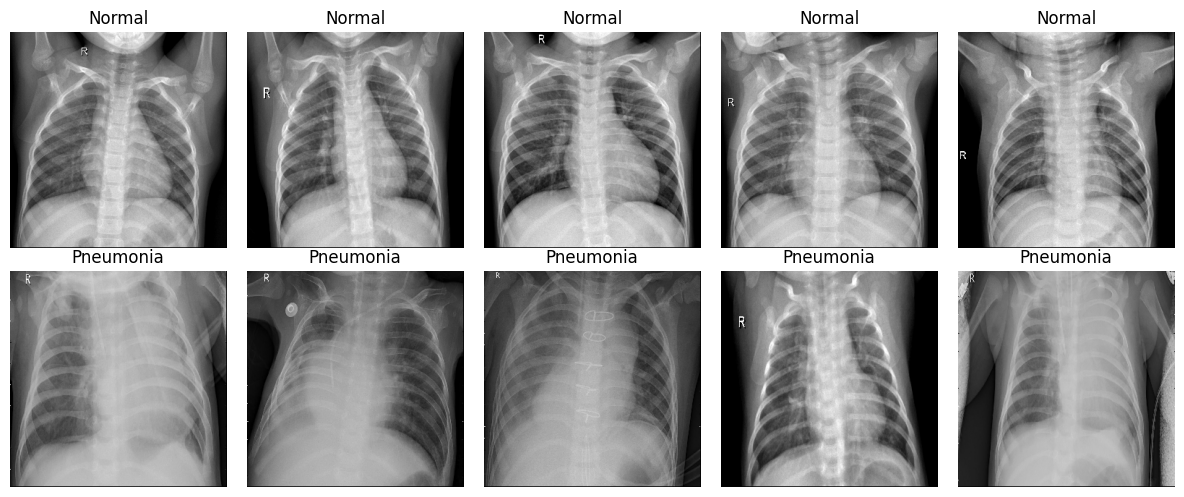

In [29]:
fig, axarr = plt.subplots(2, 5, figsize=(12,5))

# normal
for i in range(5):
    axarr[0, i].imshow(data[0][i], cmap='gray')
    axarr[0, i].set_title('Normal')
    axarr[0, i].axis('off')

# pneumonia
for i in range(5):
    axarr[1, i].imshow(data[1][i], cmap='gray')
    axarr[1, i].set_title('Pneumonia')
    axarr[1, i].axis('off')

plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [ ]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [30]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [36]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.concatenate([
    np.zeros(TRAINING_COUNT, dtype=np.int32),   # normal
    np.ones(TRAINING_COUNT, dtype=np.int32),    # pneumonia
    np.full(TRAINING_COUNT, 2, dtype=np.int32)  # covid
])

In [41]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [42]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.concatenate([
    np.zeros(TESTING_COUNT, dtype=np.int32),   # normal
    np.ones(TESTING_COUNT, dtype=np.int32),    # pneumonia
    np.full(TESTING_COUNT, 2, dtype=np.int32)  # covid
])

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [43]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [44]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [45]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [ ]:
# TODO: In just a few sentences, please explain how the Random Forest works.

A Random Forest builds many decision trees using different random subsets of the data and features. Each tree makes a prediction, and the final result is the majority vote (for classification). By combining many diverse trees, it reduces overfitting and improves overall accuracy compared to a single decision tree.

In [46]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.9083333333333333

In [ ]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [ ]:
# TODO: it is good classifcation accuracy, the dataset is relatively structured, with a powerful model and many features.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [ ]:
# TODO: 100

In [ ]:
# Now, please use a single tree and observe the testing performance.

In [49]:
# TODO:
clf = RandomForestClassifier(n_estimators=100)
fitted = clf.fit( X_train, y_train )
clf.score( X_test, y_test )

0.9166666666666666

In [ ]:
# Are you surprised?

In [ ]:
# TODO: No, because a single tree tends to overfit and has higher variance,
# while Random Forest uses many trees to improve stability and accuracy.

**Bonus:** Let's take a closer look! [33 Points]

In [ ]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [50]:
# TODO: YOUR CODE AND YOUR ANSWER
remaining_covid = data[2][TRAINING_COUNT + TESTING_COUNT:]

X_test_covid_only = np.zeros((len(remaining_covid), 300*300), dtype=np.float32)

for i, image in enumerate(remaining_covid):
    image = image.ravel().astype(np.float32)
    if image.max() > 0:
        image /= image.max()
    X_test_covid_only[i] = image

y_test_covid_only = np.full(len(remaining_covid), 2, dtype=np.int32)

# Evaluate
covid_acc = clf.score(X_test_covid_only, y_test_covid_only)
print("Accuracy on remaining covid images:", covid_acc)

# Predictions
predictions = clf.predict(X_test_covid_only)
print("Predicted label counts:", np.bincount(predictions, minlength=3))

Accuracy on remaining covid images: 0.9595959595959596
Predicted label counts: [ 0  4 95]


In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

Number of misclassified covid images: 4
Misclassified indices: [ 3 32 40 85]


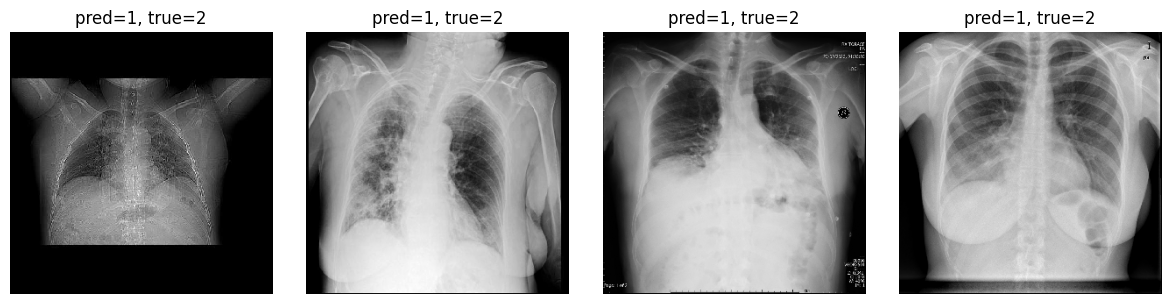

In [53]:
# TODO: YOUR CODE AND YOUR ANSWER
mis_idx = np.where(predictions != y_test_covid_only)[0]
print("Number of misclassified covid images:", len(mis_idx))
print("Misclassified indices:", mis_idx)

num_show = 10 if len(mis_idx) > 10 else len(mis_idx)

fig, axes = plt.subplots(1, num_show, figsize=(3*num_show, 3))

if num_show == 1:
    axes = [axes]

for ax, idx in zip(axes, mis_idx[:num_show]):
    ax.imshow(remaining_covid[idx], cmap='gray')
    ax.set_title(f"pred={predictions[idx]}, true=2")
    ax.axis('off')

plt.tight_layout()
plt.show()

These images were likely misclassified because they look more similar to pneumonia than to typical COVID cases. COVID and pneumonia can have overlapping patterns on chest X-rays, so the classifier confused them. Also, flattening the images into pixel vectors removes spatial information, which makes it harder to distinguish subtle disease patterns.

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw